## 05 - Recommendation Design and Physical Expansion

### Objetivo
Responder a lo siguiente:

- 4. Diseño de una arquitectura y flujo lógico para recomendación automática en tiempo real.
- 5. Identificación de la mejor ciudad para ubicar una tienda insignia física.

### Parte A — Recomendación en tiempo real

#### Enfoque propuesto
Se plantea un recomendador híbrido y explicable:

1. Identificar el segmento del cliente.
2. Recuperar historial de compras.
3. Generar candidatos:
   - top productos de su categoría preferida,
   - productos populares dentro de su segmento,
   - productos complementarios a su historial.
4. Filtrar productos ya comprados recientemente.
5. Rankear según reglas de negocio.
6. Servir recomendaciones en tiempo real.

In [14]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets
from src.analysis.site_selection import (
    build_city_sales_summary,
    add_city_priority_score,
)

TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

processed_dir = PROJECT_ROOT / "data" / "processed"
customer_360_features = pd.read_csv(processed_dir / "customer_360_features.csv")

In [32]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
orders = bundle.orders.copy()
order_items = bundle.order_items.copy()
products = bundle.products.copy()
translation = bundle.product_category_translation.copy()

In [33]:

delivered_orders = orders.loc[orders["order_status"] == "delivered"].copy()

order_value = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        order_revenue=("price", "sum"),
        freight_total=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
    )
)

order_base = (
    delivered_orders
    .merge(order_value, on="order_id", how="inner", validate="one_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
)

order_base.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_revenue,freight_total,n_items,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [34]:
item_base = (
    order_items
    .merge(
        orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]],
        on="order_id",
        how="inner"
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        translation,
        on="product_category_name",
        how="left"
    )
)

item_base = item_base.loc[item_base["order_status"] == "delivered"].copy()

item_base["product_category"] = (
    item_base["product_category_name_english"]
    .fillna(item_base["product_category_name"])
    .fillna("unknown")
)

item_base["item_revenue"] = item_base["price"].fillna(0.0)

item_base.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,customer_unique_id,product_category_name,product_category_name_english,product_category,item_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,871766c5855e863f6eccc05f988b23cb,cool_stuff,cool_stuff,cool_stuff,58.90
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,eb28e67c4c0b83846050ddfb8a35d051,pet_shop,pet_shop,pet_shop,239.90
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,3818d81c6709e39d06b2738a8d3a2474,moveis_decoracao,furniture_decor,furniture_decor,199.00
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,af861d436cfc08b2c2ddefd0ba074622,perfumaria,perfumery,perfumery,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,64b576fb70d441e8f1b2d7d446e483c5,ferramentas_jardim,garden_tools,garden_tools,199.90


In [35]:
customer_profile = (
    customer_360_features[[
        "customer_unique_id",
        "segment_code",
        "customer_segment_primary",
        "segment_alias",
        "customer_flags_text",
        "favorite_category",
        "purchase_history_summary",
    ]]
    .merge(
        item_base.groupby("customer_unique_id", as_index=False)
        .agg(
            total_orders=("order_id", "nunique"),
            total_spend=("item_revenue", "sum"),
        ),
        on="customer_unique_id",
        how="left"
    )
)

customer_profile.head()

,customer_unique_id,segment_code,customer_segment_primary,segment_alias,customer_flags_text,favorite_category,purchase_history_summary,total_orders,total_spend
0,0000366f3b9a7992bf8c76cfdf3221e2,S3,OCCASIONAL,Comprador esporádico,FRICTION_RISK,bed_bath_table,Top categories: bed_bath_table,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,S3,OCCASIONAL,Comprador esporádico,FRICTION_RISK,health_beauty,Top categories: health_beauty,1,18.90
2,0000f46a3911fa3c0805444483337064,S4,CHURN_RISK,En riesgo de abandono,"FRICTION_RISK, CHURN_SIGNAL",stationery,Top categories: stationery,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,S3,OCCASIONAL,Comprador esporádico,FRICTION_RISK,telephony,Top categories: telephony,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,S3,OCCASIONAL,Comprador esporádico,FRICTION_RISK,telephony,Top categories: telephony,1,180.00


In [37]:
popular_products_by_category = (
    item_base.groupby(["product_category", "product_id"], as_index=False)
    .agg(
        total_volume=("order_item_id", "count"),
        total_revenue=("item_revenue", "sum"),
    )
    .sort_values(
        ["product_category", "total_volume", "total_revenue"],
        ascending=[True, False, False]
    )
)

popular_products_by_category.head()

,product_category,product_id,total_volume,total_revenue
7,agro_industry_and_commerce,11250b0d4b709fee92441c5f34122aed,22,9111.00
23,agro_industry_and_commerce,423a6644f0aa529e8828ff1f91003690,18,8043.00
33,agro_industry_and_commerce,672e757f331900b9deea127a2a7b79fd,17,6885.00
38,agro_industry_and_commerce,a0fe1efb855f3e786f0650268cd77f44,13,407.87
21,agro_industry_and_commerce,3bebad3cf2c8d1a8d3ce97174643e054,13,266.00


In [38]:
popular_products_by_segment = (
    item_base
    .merge(
        customer_360_features[["customer_unique_id", "customer_segment_primary"]],
        on="customer_unique_id",
        how="left"
    )
    .groupby(["customer_segment_primary", "product_id", "product_category"], as_index=False)
    .agg(
        total_volume=("order_item_id", "count"),
        total_revenue=("item_revenue", "sum"),
    )
    .sort_values(
        ["customer_segment_primary", "total_volume", "total_revenue"],
        ascending=[True, False, False]
    )
)

popular_products_by_segment.head()

,customer_segment_primary,product_id,product_category,total_volume,total_revenue
3534,CHURN_RISK,99a4788cb24856965c36a24e339b6058,bed_bath_table,214,19238.60
520,CHURN_RISK,154e7e31ebfa092203795c972e5804a6,health_beauty,103,2170.97
4590,CHURN_RISK,c6dd917a0be2a704582055949915ab32,cool_stuff,99,9799.01
2887,CHURN_RISK,7c1bd920dbdf22470b68bde975dd3ccf,health_beauty,80,4899.20
1558,CHURN_RISK,42a2c92a0979a949ca4ea89ec5c7b934,housewares,64,3833.60


### MVP lógico del recomendador

#### Entrada
- `customer_unique_id`
- segmento del cliente
- categoría favorita
- historial reciente

#### Salida
- top N productos recomendados

#### Regla base
Score = popularidad en categoría + popularidad en segmento - penalización por compra reciente

In [39]:
def recommend_products_for_customer(
    customer_unique_id: str,
    customer_profile: pd.DataFrame,
    item_base: pd.DataFrame,
    popular_products_by_category: pd.DataFrame,
    popular_products_by_segment: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    profile = customer_profile.loc[
        customer_profile["customer_unique_id"] == customer_unique_id
    ]

    if profile.empty:
        return pd.DataFrame()

    segment = profile["customer_segment_primary"].iloc[0]
    favorite_category = profile["favorite_category"].iloc[0]
    flags_text = profile["customer_flags_text"].iloc[0]

    already_bought = set(
        item_base.loc[
            item_base["customer_unique_id"] == customer_unique_id,
            "product_id"
        ].unique()
    )

    candidates_cat = popular_products_by_category.loc[
        popular_products_by_category["product_category"] == favorite_category
    ][["product_id", "product_category", "total_volume", "total_revenue"]].copy()
    candidates_cat["score_cat"] = candidates_cat["total_volume"]

    candidates_seg = popular_products_by_segment.loc[
        popular_products_by_segment["customer_segment_primary"] == segment
    ][["product_id", "product_category", "total_volume", "total_revenue"]].copy()
    candidates_seg["score_seg"] = candidates_seg["total_volume"]
    candidates_seg = candidates_seg.rename(columns={"product_category": "product_category_seg"})

    candidates = (
        candidates_cat[["product_id", "product_category", "score_cat"]]
        .merge(
            candidates_seg[["product_id", "product_category_seg", "score_seg"]],
            on="product_id",
            how="outer"
        )
    )

    # conservar la categoría real, no convertirla en 0
    candidates["product_category"] = candidates["product_category"].combine_first(
        candidates["product_category_seg"]
    )
    candidates = candidates.drop(columns=["product_category_seg"])

    # solo scores numéricos se llenan con 0
    candidates["score_cat"] = candidates["score_cat"].fillna(0.0)
    candidates["score_seg"] = candidates["score_seg"].fillna(0.0)

    # score base
    candidates["score"] = 0.6 * candidates["score_cat"] + 0.4 * candidates["score_seg"]

    # ajuste si el cliente tiene fricción
    if "FRICTION_RISK" in flags_text:
        candidates["score"] = 0.5 * candidates["score_cat"] + 0.5 * candidates["score_seg"]

    candidates = candidates.loc[
        ~candidates["product_id"].isin(already_bought)
    ].copy()

    # prioridad 1: misma categoría favorita
    same_category = candidates.loc[
        candidates["product_category"] == favorite_category
    ].copy().sort_values("score", ascending=False)

    # prioridad 2: fallback por segmento
    fallback = candidates.loc[
        candidates["product_category"] != favorite_category
    ].copy().sort_values("score", ascending=False)

    result = (
        pd.concat([same_category, fallback], axis=0)
        .drop_duplicates(subset=["product_id"])
        .head(top_n)
        .reset_index(drop=True)
    )

    return result

In [42]:
example_customer = customer_profile["customer_unique_id"].dropna().iloc[1]

recommend_products_for_customer(
    customer_unique_id=example_customer,
    customer_profile=customer_profile,
    item_base=item_base,
    popular_products_by_category=popular_products_by_category,
    popular_products_by_segment=popular_products_by_segment,
    top_n=10,
)

,product_id,product_category,score_cat,score_seg,score
0,2b4609f8948be18874494203496bc318,health_beauty,255.0,161.0,208.0
1,154e7e31ebfa092203795c972e5804a6,health_beauty,274.0,137.0,205.5
2,7c1bd920dbdf22470b68bde975dd3ccf,health_beauty,220.0,108.0,164.0
3,bb50f2e236e5eea0100680137654686c,health_beauty,194.0,126.0,160.0
4,437c05a395e9e47f9762e677a7068ce7,health_beauty,151.0,126.0,138.5
5,6cdd53843498f92890544667809f1595,health_beauty,153.0,91.0,122.0
6,e0cf79767c5b016251fe139915c59a26,health_beauty,137.0,99.0,118.0
7,4c2394abfbac7ff59ec7a420918562fa,health_beauty,120.0,114.0,117.0
8,3fbc0ef745950c7932d5f2a446189725,health_beauty,149.0,65.0,107.0
9,19c91ef95d509ea33eda93495c4d3481,health_beauty,154.0,46.0,100.0


## Arquitectura propuesta para producción

### Componentes
1. Web/App
2. API de perfil de cliente
3. Feature store / customer profile store
4. Candidate generator
5. Ranking service
6. Cache de recomendaciones
7. Logging + feedback loop

### Flujo
1. El usuario entra a la web.
2. La API consulta su segmento y comportamiento.
3. Se generan candidatos por categoría, popularidad y segmento.
4. Se rankean recomendaciones.
5. Se devuelven top N productos.
6. El clic o compra alimenta reentrenamiento futuro.

## Parte B — Mejor ciudad para expansión física

### Supuesto
Como el dataset no trae coordenada exacta de tienda ideal ni tráfico físico, se prioriza la ciudad con base en:
- ingresos
- número de órdenes
- número de clientes únicos
- ticket promedio

In [27]:
from src.analysis.site_selection import (
    build_city_sales_summary,
    add_city_priority_score,
)

In [28]:
city_summary = build_city_sales_summary(order_base)
city_priority = add_city_priority_score(city_summary)

city_priority.head(15)

,customer_state,customer_city,n_orders,n_customers,total_revenue,avg_order_value,total_items,revenue_norm,orders_norm,customers_norm,aov_norm,city_priority_score
0,SP,sao paulo,15045,14528,1859556.83,123.599656,17400,1.000000,1.000000,1.000000,0.053773,0.905377
1,RJ,rio de janeiro,6601,6361,955573.97,144.762001,7592,0.513870,0.438713,0.437805,0.063417,0.434823
2,MG,belo horizonte,2697,2606,346039.04,128.305169,3087,0.186084,0.179208,0.179321,0.055917,0.169996
3,DF,brasilia,2071,2013,295814.72,142.836659,2341,0.159076,0.137596,0.138501,0.062539,0.139937
4,PB,pianco,1,1,2200.00,2200.000000,1,0.001180,0.000000,0.000000,1.000000,0.100531
5,PA,nova esperanca do piria,1,1,2199.00,2199.000000,1,0.001180,0.000000,0.000000,0.999544,0.100485
6,PR,curitiba,1489,1434,205999.33,138.347435,1727,0.110776,0.098910,0.098644,0.060494,0.100355
7,AL,sao sebastiao,1,1,2159.98,2159.980000,2,0.001159,0.000000,0.000000,0.981763,0.098698
8,SP,campinas,1406,1363,184657.87,131.335612,1626,0.099299,0.093393,0.093756,0.057298,0.092514
9,MG,engenheiro navarro,1,1,1997.00,1997.000000,1,0.001071,0.000000,0.000000,0.907492,0.091231


In [29]:
top_city = city_priority.iloc[0]
top_city

customer_state                 SP
customer_city           sao paulo
n_orders                    15045
n_customers                 14528
total_revenue          1859556.83
avg_order_value        123.599656
total_items                 17400
revenue_norm                  1.0
orders_norm                   1.0
customers_norm                1.0
aov_norm                 0.053773
city_priority_score      0.905377
Name: 0, dtype: object

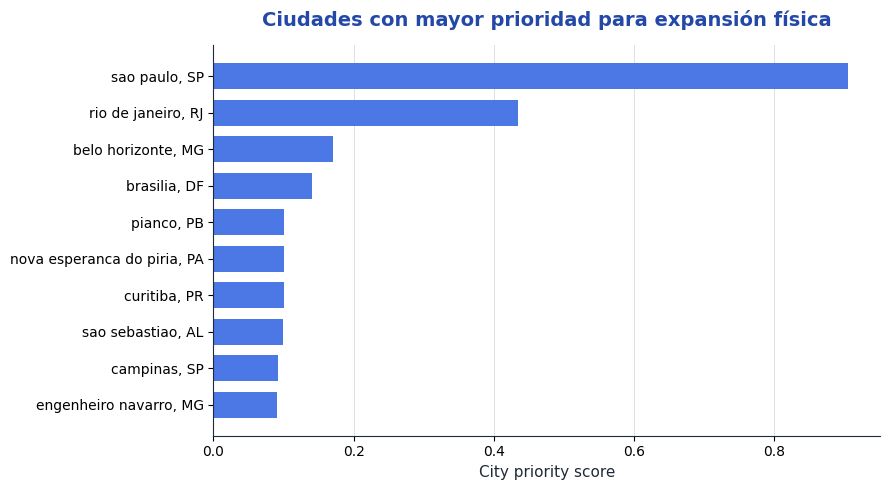

In [30]:
# ## Lectura ejecutiva del punto 5

# La ciudad recomendada debe justificar:
# - mayor escala comercial
# - mayor base de clientes
# - buen ticket promedio
# - y consistencia de demanda

import matplotlib.pyplot as plt

TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

plot_df = city_priority.head(10).sort_values("city_priority_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

labels = plot_df["customer_city"] + ", " + plot_df["customer_state"]

ax.barh(
    labels,
    plot_df["city_priority_score"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72
)

ax.set_title(
    "Ciudades con mayor prioridad para expansión física",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)

ax.set_xlabel("City priority score", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
